In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
from scipy.stats.mstats import gmean

import matplotlib.ticker as mtick 

import requests, io             # internet and input tools  
import zipfile as zf            # zip file tools 
import os  

import pyarrow as pa
import pyarrow.parquet as pq

In [ ]:
target_date = "2026-05"

data_repo = "C:\\heroku\\how-restrictive-us-trade\\data\\"

country_list = pd.read_csv(os.path.join(data_repo, "country-list.csv"), header=None, names=["CTY_CODE"])

figfile = "C:\\github\\how-restrictive-us-trade-paper\\figures\\"

texfile = "C:\\github\\how-restrictive-us-trade-paper\\results.tex"

tabletex = "C:\\github\\how-restrictive-us-trade-paper\\table.tex"



In [3]:
def make_tariff_country_date(dfcntry, date):
   
   bar = dfcntry[(dfcntry['time'] == date)].copy()

   bar["tariff"] = bar["CAL_DUT_MO"] / bar["CON_VAL_MO"]

   bar = bar[["I_COMMODITY", "CON_VAL_MO", "CAL_DUT_MO", "tariff", "CTY_NAME"]]

   return bar

In [4]:
def make_good_country_year(dfcntry, year):
    """
    Process country data for a specific year and calculate aggregate metrics.
    
    Parameters:
    -----------
    dfcntry : pandas.DataFrame
        DataFrame containing country trade data with columns:
        - time: datetime
        - I_COMMODITY: commodity code
        - CON_VAL_MO: consumption value
        - CAL_DUT_MO: calculated duty
        - CTY_NAME: country name
    year : str
        Year to filter data (e.g., "2024")
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated data by commodity for the specified year
    """
    # Filter to specific year
    df_year = dfcntry[dfcntry['time']== year]
    
    # Group by commodity and aggregate
    grp = df_year.groupby("I_COMMODITY")
    
    result = grp.agg({
        "CON_VAL_MO": "sum",
        "CAL_DUT_MO": "sum",
        "CTY_NAME": "first"})
    
    
    return result

In [5]:
country_list.head()

,CTY_CODE
0,5700
1,2010
2,1220
3,5880
4,4280


In [6]:
def process_countries_for_date(country_list, target_date, weight_year="2024", selected_country=None):
    """
    Process multiple countries and create combined dataset with weights.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    target_date : str
        Date to extract tariff data for (e.g., "2025-08")
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    selected_country : str, optional
        Country name to filter results (e.g., "CANADA"). If None, returns all countries (default: None)
    
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with tariff data and weights for all countries (or selected country)
    """
    # Handle both DataFrame and list inputs
    if isinstance(country_list, pd.DataFrame):
        countries = country_list.CTY_CODE
    else:
        countries = country_list
    
    all_results = []
    tariff_results = []
    
    for country in countries:
        
        file = os.path.join(data_repo, f"imports-hs10\\{country}data-current.parquet")
        
        # Load country data
        dfcntry = pq.read_table(file).to_pandas()
        
        dfcntry["CAL_DUT_MO"] = dfcntry["CAL_DUT_MO"].astype(float)

        dfcntry["CON_VAL_MO"] = dfcntry["CON_VAL_MO"].astype(float)

        dfcntry.time = pd.to_datetime(dfcntry.time, format="%Y-%m")

        dfcntry["applied_tariff"] = dfcntry["CAL_DUT_MO"] / dfcntry["CON_VAL_MO"]
            
        # Calculate metrics for weight year
        results_df = make_good_country_year(dfcntry, weight_year)

        results_df.reset_index(inplace=True)
        
        # Get tariff data for target date
        tariff_df = make_tariff_country_date(dfcntry, target_date)

        tariff_df.reset_index(drop=True, inplace=True)
        
        # Add to lists
        all_results.append(results_df)

        tariff_results.append(tariff_df)
        
        print(f"Processed {country}: {results_df['CTY_NAME'].iloc[0]}")
    
    # Combine all results into one dataframe
    combined_results = pd.concat(all_results)
    combined_results.reset_index(drop=True, inplace=True)
    
    combined_tariff_results = pd.concat(tariff_results)
    combined_tariff_results.reset_index(drop=True, inplace=True)
    
    # Calculate weights
    combined_results["weights"] = combined_results["CON_VAL_MO"] / combined_results["CON_VAL_MO"].sum()
    
    # Merge weights with tariff data
    bigdf = pd.merge(
        combined_results[["I_COMMODITY", "CTY_NAME", "weights"]], 
        combined_tariff_results, 
        how="left", 
        on=["I_COMMODITY", "CTY_NAME"]
    )
    
    # Filter to selected country if specified
    if selected_country is not None:
        bigdf = bigdf[bigdf["CTY_NAME"] == selected_country].copy()
        # Renormalize weights to sum to 1 for the selected country
        bigdf["weights"] = bigdf["weights"] / bigdf["weights"].sum()
    
    return bigdf

In [7]:
def create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024"):
    """
    Calculate tariff metrics for multiple dates and countries.
    
    Parameters:
    -----------
    country_list : pandas.DataFrame or list
        DataFrame with CTY_CODE column or list of country codes
    date_list : list
        List of date strings to process (e.g., ["2024-08", "2025-02", "2025-08"])
    weight_year : str, optional
        Year to use for calculating weights (default: "2024")
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with columns: date, CTY_NAME, sqrtariff, meanweighted, simplemean
    """
    results = []
    
    for date in date_list:
        print(f"Processing date: {date}")
        
        # Get data for this date (all countries)
        bigdf = process_countries_for_date(country_list, date, weight_year=weight_year)
        
        # Calculate metrics for ALL COUNTRIES combined
        sqrtariff_all = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5
        meanweighted_all = (bigdf["tariff"] * bigdf["weights"]).sum()
        simplemean_all = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()
        
        # Store ALL COUNTRIES results
        results.append({
            'date': date,
            'CTY_NAME': 'ALL COUNTRIES',
            'sqrtariff': sqrtariff_all,
            'meanweighted': meanweighted_all,
            'simplemean': simplemean_all,
            "duty_total": bigdf['CAL_DUT_MO'].sum()
        })
        
        # Get unique countries in this dataset
        countries = bigdf['CTY_NAME'].unique()
        
        for country in countries:
            # Filter to this country
            country_df = bigdf[bigdf['CTY_NAME'] == country].copy()
            
            # Renormalize weights to sum to 1 for this country
            country_df["weights"] = country_df["weights"] / country_df["weights"].sum()
            
            # Calculate metrics
            sqrtariff = ((country_df["tariff"]**2 * country_df["weights"]).sum())**0.5
            meanweighted = (country_df["tariff"] * country_df["weights"]).sum()
            simplemean = country_df['CAL_DUT_MO'].sum() / country_df["CON_VAL_MO"].sum()
            
            # Store results
            results.append({
                'date': date,
                'CTY_NAME': country,
                'sqrtariff': sqrtariff,
                'meanweighted': meanweighted,
                'simplemean': simplemean,
                "duty_total": country_df['CAL_DUT_MO'].sum()
            })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

In [8]:
bigdf = process_countries_for_date(country_list, target_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

# Format the date

formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

with open(texfile, 'w') as f:
    f.write(f'\\newcommand{{\\rmsValuetwofive}}{{{sqrtariff*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\meanWeightedValuetwofive}}{{{meanweighted*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\simpleMeanValuetwofive}}{{{simplemean*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\currentdate}}{{{formatted_date}}}\n')
    f.write(f'\\newcommand{{\\diffmeanWeightedValuetwofive}}{{{(sqrtariff*100 - meanweighted*100):.0f}}}\n')
    f.write(f'\\newcommand{{\\diffsimpleMeanValuetwofive}}{{{(sqrtariff*100 - simplemean*100):.0f}}}\n')


Processed 5700: CHINA
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 4190: IRELAND
Processed 5330: INDIA
Processed 4120: UNITED KINGDOM
Processed 4759: ITALY
Processed 4279: FRANCE
Processed 4419: SWITZERLAND
Processed 5570: MALAYSIA
Processed 5490: THAILAND
Processed 3510: BRAZIL
Processed 5590: SINGAPORE
Processed 4210: NETHERLANDS
Processed 5600: INDONESIA
Processed 5081: ISRAEL
Processed 4231: BELGIUM
Processed 5170: SAUDI ARABIA
Processed 4700: SPAIN
Processed 4621: RUSSIA
Processed 3010: COLOMBIA
Processed 4330: AUSTRIA
Processed 6021: AUSTRALIA
Processed 4010: SWEDEN
Processed 3370: CHILE
Weighted TRI Tariff: 18.02%
 
Weighted Mean Tariff: 10.81%
 
Simple Mean Tariff: 8.52%


In [9]:
# # Export histogram data to CSV
# histogram_data = pd.DataFrame({
#     'bin_edges': bin_edges[:-1],
#     'fractions': fractions
# })

# histogram_data.to_csv(data_repo + f"histogram_data_{target_date}.csv", index=False)

# print(f"Histogram data exported to: {data_repo}histogram_data_{target_date}.csv")

In [10]:
bigdf["tariff"].describe()

count    82950.000000
mean         0.193152
std          0.161549
min          0.000000
25%          0.099986
50%          0.150003
75%          0.261371
max          2.624275
Name: tariff, dtype: float64

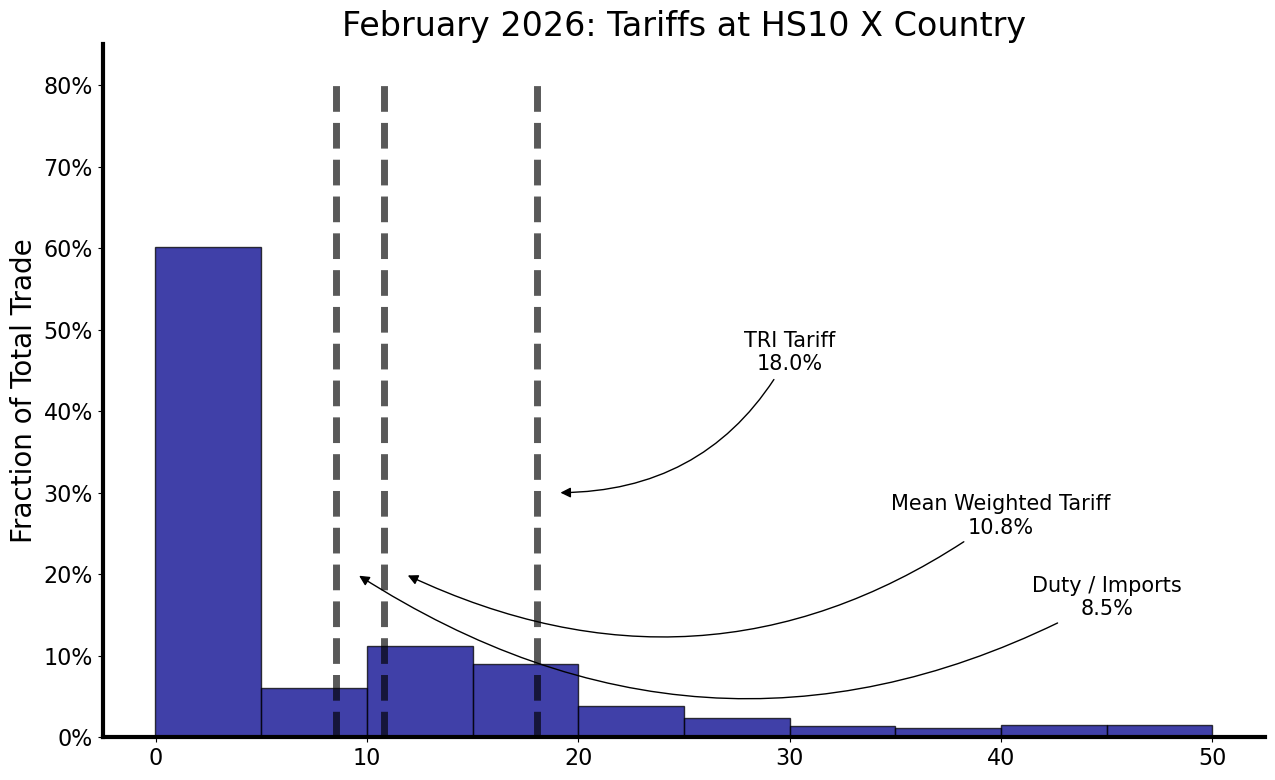

In [11]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-.01, 50, 11)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkblue', alpha=0.75, edgecolor='black')

# ax.set_ylim(top=0.95)

ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")
ax.set_title(f"{formatted_date}: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.vlines(100*sqrtariff, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("TRI Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Weighted Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*simplemean, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Duty / Imports\n{:.1f}%".format(100*simplemean), 
            xy=(100*simplemean+1, 0.20), 
            xytext=(45, 0.15),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

plt.savefig(figfile+ target_date + "-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+ target_date + "-histogram.pdf", bbox_inches = "tight")

plt.show()

In [12]:
# Create comparison date for prior year (2024)
comparison_date = "2024-" + target_date.split("-")[1] 

bigdf = process_countries_for_date(country_list, comparison_date, weight_year="2024")

sqrtariff = ((bigdf["tariff"]**2 * bigdf["weights"]).sum())**0.5

print(f"Weighted TRI Tariff: {sqrtariff:.2%}")

meanweighted = (bigdf["tariff"] * bigdf["weights"]).sum()

print(" ")

print(f"Weighted Mean Tariff: {meanweighted:.2%}")

print(" ")

simplemean = bigdf['CAL_DUT_MO'].sum() / bigdf["CON_VAL_MO"].sum()

print(f"Simple Mean Tariff: {simplemean:.2%}")

formatted_date = pd.to_datetime(comparison_date, format="%Y-%m").strftime("%B %Y")

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\rmsValuetwofour}}{{{sqrtariff*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\meanWeightedValuetwofour}}{{{meanweighted*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\simpleMeanValuetwofour}}{{{simplemean*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\olddate}}{{{formatted_date}}}\n')


Processed 5700: CHINA
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 4190: IRELAND
Processed 5330: INDIA
Processed 4120: UNITED KINGDOM
Processed 4759: ITALY
Processed 4279: FRANCE
Processed 4419: SWITZERLAND
Processed 5570: MALAYSIA
Processed 5490: THAILAND
Processed 3510: BRAZIL
Processed 5590: SINGAPORE
Processed 4210: NETHERLANDS
Processed 5600: INDONESIA
Processed 5081: ISRAEL
Processed 4231: BELGIUM
Processed 5170: SAUDI ARABIA
Processed 4700: SPAIN
Processed 4621: RUSSIA
Processed 3010: COLOMBIA
Processed 4330: AUSTRIA
Processed 6021: AUSTRALIA
Processed 4010: SWEDEN
Processed 3370: CHILE
Weighted TRI Tariff: 6.90%
 
Weighted Mean Tariff: 2.52%
 
Simple Mean Tariff: 2.49%


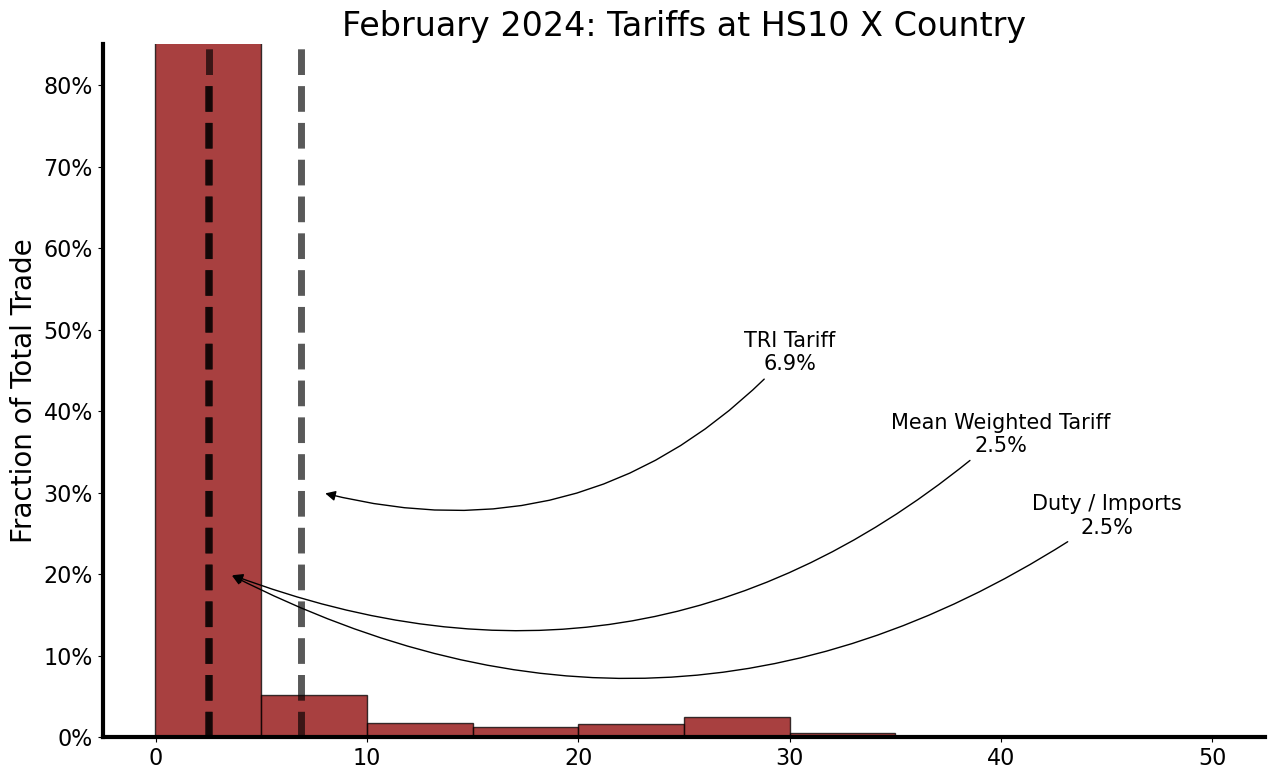

In [13]:
fig, ax = plt.subplots(figsize = (15,9))

# fig = plt.figure(figsize=(15, 9))
# bax_ax = bax.brokenaxes(ylims=((0, 0.20), (0.40, 0.50)), hspace=.05)

bin_edges = np.linspace(-.01, 50, 11)  # 50 bins

# Digitize delta_tariff into bins
bin_indices = np.digitize(100*bigdf["tariff"], bin_edges) - 1

# Sum CON_VAL_MO in each bin
bin_sums = np.zeros(len(bin_edges) - 1)

for i in range(len(bin_sums)):

    bin_sums[i] = bigdf.loc[bin_indices == i, "CON_VAL_MO"].sum()

# Convert to fraction of total CON_VAL_MO
fractions = bin_sums / bigdf["CON_VAL_MO"].sum()

ax.bar(bin_edges[:-1], fractions, width=np.diff(bin_edges), 
       align='edge', color='darkred', alpha=0.75, edgecolor='black')



ax.set_ylabel("Fraction of Total Trade", fontsize = 20)

# ax.set_xlabel("Change in HS10 Tariff: May 2025 - May 2024", fontsize = 20)

formatted_date = pd.to_datetime(comparison_date, format="%Y-%m").strftime("%B %Y")
ax.set_title(f"{formatted_date}: Tariffs at HS10 X Country", fontsize = 24)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

# mediantariff = foo["applied_tariff"].median()

ax.vlines(100*sqrtariff, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("TRI Tariff\n{:.1f}%".format(100*sqrtariff), 
            xy=(100*sqrtariff+1, 0.3), 
            xytext=(30, 0.45),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*meanweighted, 0, 0.85, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Mean Weighted Tariff\n{:.1f}%".format(100*meanweighted), 
            xy=(100*meanweighted+1, 0.20), 
            xytext=(40, 0.35),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')


ax.vlines(100*simplemean, 0, 0.80, 
          linestyles= "dashed", color = "k", linewidth=5, alpha=0.65)

ax.annotate("Duty / Imports\n{:.1f}%".format(100*simplemean), 
            xy=(100*simplemean+1, 0.20), 
            xytext=(45, 0.25),
            arrowprops={
            "arrowstyle": "-|>", # This is stuff about the arrow
            "connectionstyle": "arc3,rad=-0.3",  # rad controls curve amount,  # Arc with arms
            "color": "black"},
            fontsize=15, color='black',
            ha='center')

ax.set_ylim(top=0.85)

plt.savefig(figfile+ comparison_date + "-histogram.png", bbox_inches = "tight")

plt.savefig(figfile+ comparison_date + "-histogram.pdf", bbox_inches = "tight")

plt.show()


In [14]:
date_list = pd.date_range(start="2024-01", end=target_date, freq="MS").strftime("%Y-%m").tolist()

metrics_df = create_tariff_metrics_by_date_country(country_list, date_list, weight_year="2024")

metrics_df["date"] = pd.to_datetime(metrics_df["date"], format="%Y-%m")

metrics_df.to_parquet(data_repo + "\\top-country-metrics.parquet", index=False)

metrics_df = pq.read_table(data_repo + "\\top-country-metrics.parquet").to_pandas()


Processing date: 2024-01
Processed 5700: CHINA
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 4190: IRELAND
Processed 5330: INDIA
Processed 4120: UNITED KINGDOM
Processed 4759: ITALY
Processed 4279: FRANCE
Processed 4419: SWITZERLAND
Processed 5570: MALAYSIA
Processed 5490: THAILAND
Processed 3510: BRAZIL
Processed 5590: SINGAPORE
Processed 4210: NETHERLANDS
Processed 5600: INDONESIA
Processed 5081: ISRAEL
Processed 4231: BELGIUM
Processed 5170: SAUDI ARABIA
Processed 4700: SPAIN
Processed 4621: RUSSIA
Processed 3010: COLOMBIA
Processed 4330: AUSTRIA
Processed 6021: AUSTRALIA
Processed 4010: SWEDEN
Processed 3370: CHILE
Processing date: 2024-02
Processed 5700: CHINA
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 4190: IRELAND
Pr

In [15]:
metrics_df.tail()

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total
801,2026-02-01,COLOMBIA,0.064974,0.025573,0.023727,34428600.0
802,2026-02-01,AUSTRIA,0.171419,0.113182,0.120425,101838474.0
803,2026-02-01,AUSTRALIA,0.084019,0.037396,0.044664,39420409.0
804,2026-02-01,SWEDEN,0.158941,0.110104,0.116235,119608364.0
805,2026-02-01,CHILE,0.072782,0.047121,0.031269,52759216.0


In [20]:
metrics_df.tail()

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total,flag,color
801,2026-02-01,COLOMBIA,0.064974,0.025573,0.023727,34428600.0,https://flagcdn.com/w40/co.png,#FCD116
802,2026-02-01,AUSTRIA,0.171419,0.113182,0.120425,101838474.0,https://flagcdn.com/w40/at.png,#ED2939
803,2026-02-01,AUSTRALIA,0.084019,0.037396,0.044664,39420409.0,https://flagcdn.com/w40/au.png,#012169
804,2026-02-01,SWEDEN,0.158941,0.110104,0.116235,119608364.0,https://flagcdn.com/w40/se.png,#006AA7
805,2026-02-01,CHILE,0.072782,0.047121,0.031269,52759216.0,https://flagcdn.com/w40/cl.png,#D52B1E


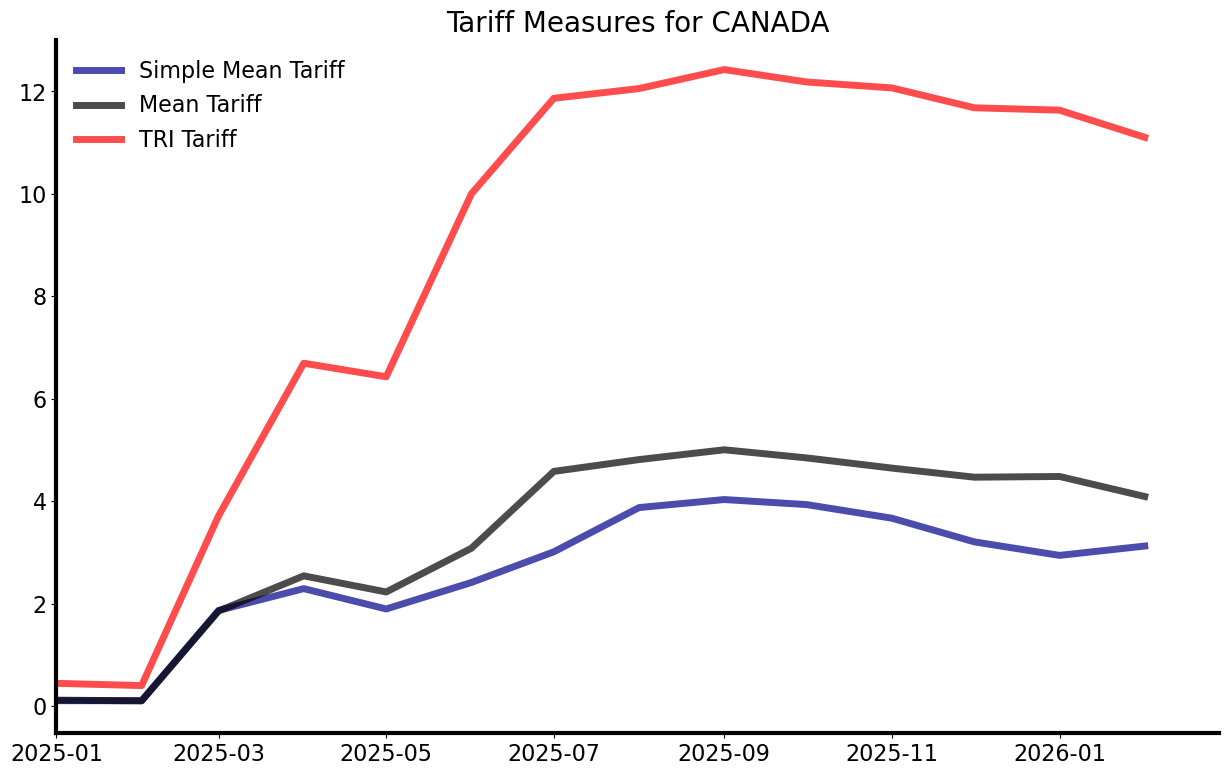

In [21]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CANADA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

plot_end = pd.to_datetime(target_date, format="%Y-%m") + pd.offsets.MonthEnd(1)
ax.set_xlim([dt.datetime(2025,1,1), plot_end])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

# plt.savefig(figfile+"canada-tariffs.png", bbox_inches = "tight")

# plt.savefig(figfile+"canada-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [22]:
# Export Canada plot data to CSV
canada_plot_data = foo[['date', 'simplemean', 'meanweighted', 'sqrtariff']].copy()
canada_plot_data['simplemean'] = 100 * canada_plot_data['simplemean']
canada_plot_data['meanweighted'] = 100 * canada_plot_data['meanweighted']
canada_plot_data['sqrtariff'] = 100 * canada_plot_data['sqrtariff']

canada_plot_data.to_csv(data_repo + f"canada_tariff_plot_data_{target_date}.csv", index=False)

print(f"Canada plot data exported to: {data_repo}canada_tariff_plot_data_{target_date}.csv")

Canada plot data exported to: C:\heroku\how-restrictive-us-trade\data\canada_tariff_plot_data_2026-02.csv


In [23]:
foo.tail()

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total,flag,color
654,2025-10-01,CANADA,0.121852,0.048445,0.039334,1.178671e+09,https://flagcdn.com/w40/ca.png,#FF0000
685,2025-11-01,CANADA,0.120702,0.046458,0.036673,1.001895e+09,https://flagcdn.com/w40/ca.png,#FF0000
716,2025-12-01,CANADA,0.116815,0.044684,0.032054,9.465996e+08,https://flagcdn.com/w40/ca.png,#FF0000
747,2026-01-01,CANADA,0.116352,0.044822,0.029414,8.122521e+08,https://flagcdn.com/w40/ca.png,#FF0000
778,2026-02-01,CANADA,0.111052,0.040912,0.031236,8.619189e+08,https://flagcdn.com/w40/ca.png,#FF0000


In [24]:
foo.head()

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\canadarmsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\canadameanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\canadasimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')


In [25]:
outfoo.sqrtariff.iloc[0]

np.float64(0.11105170860437778)

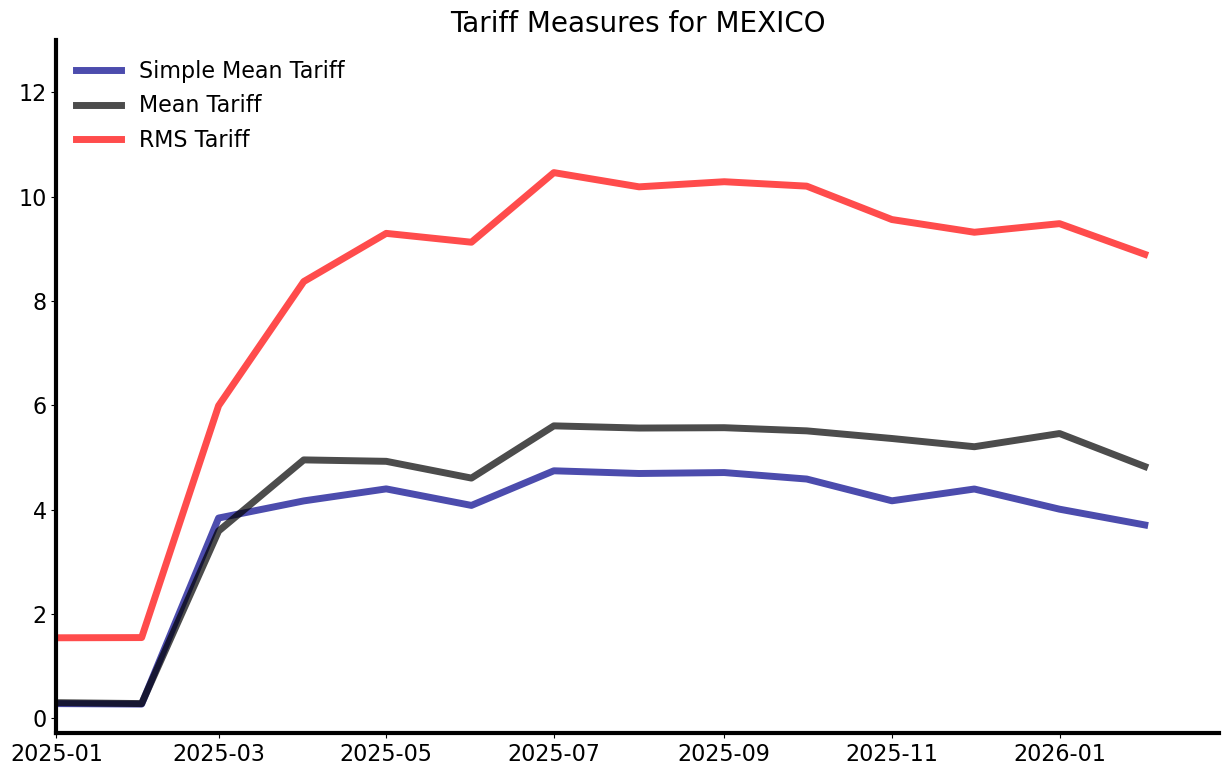

In [26]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "MEXICO"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "RMS Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

plot_end = pd.to_datetime(target_date, format="%Y-%m") + pd.offsets.MonthEnd(1)
ax.set_xlim([dt.datetime(2025,1,1), plot_end])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

ax.set_ylim(top=13)

plt.savefig(figfile+"mexico-tariffs.png", bbox_inches = "tight")

plt.savefig(figfile+"mexico-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [27]:
# Export Mexico plot data to CSV
mexico_plot_data = foo[['date', 'simplemean', 'meanweighted', 'sqrtariff']].copy()
mexico_plot_data['simplemean'] = 100 * mexico_plot_data['simplemean']
mexico_plot_data['meanweighted'] = 100 * mexico_plot_data['meanweighted']
mexico_plot_data['sqrtariff'] = 100 * mexico_plot_data['sqrtariff']

mexico_plot_data.to_csv(data_repo + f"mexico_tariff_plot_data_{target_date}.csv", index=False)
print(f"Mexico plot data exported to: {data_repo}mexico_tariff_plot_data_{target_date}.csv")

Mexico plot data exported to: C:\heroku\how-restrictive-us-trade\data\mexico_tariff_plot_data_2026-02.csv


In [28]:
foo.head()

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\mexicormsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\mexicomeanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\mexicosimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')


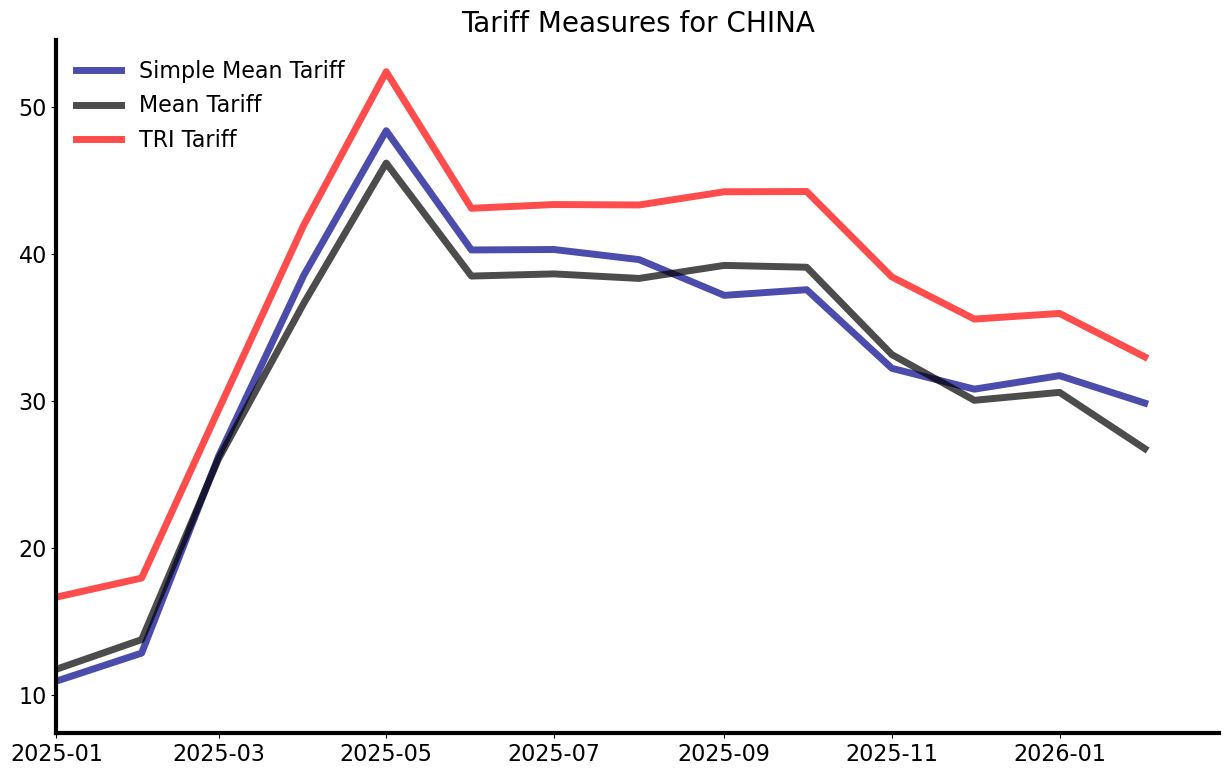

In [29]:
fig, ax = plt.subplots(figsize = (15,9))

foo = metrics_df[metrics_df["CTY_NAME"] == "CHINA"].copy()

ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Simple Mean Tariff")

ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Tariff")

ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

ax.set_title("Tariff Measures for " + foo["CTY_NAME"].iloc[0], fontsize = 20)

plot_end = pd.to_datetime(target_date, format="%Y-%m") + pd.offsets.MonthEnd(1)
ax.set_xlim([dt.datetime(2025,1,1), plot_end])

ax.tick_params(axis='x', labelsize=16)  # Change font size of x-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

ax.spines["right"].set_visible(False)

ax.spines["top"].set_visible(False)

ax.spines["left"].set_linewidth(3)

ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,           # Font size
    frameon=False,         # No box
    loc='upper left',     # Position
    ncol=1                 # Number of columns
)

plt.savefig(figfile+"china-tariffs.png", bbox_inches = "tight")

plt.savefig(figfile+"china-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [30]:
foo.head()

outfoo = foo[foo["date"] == pd.to_datetime(target_date, format="%Y-%m")].copy()

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\chinarmsValuetwofive}}{{{outfoo.sqrtariff.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\chinameanWeightedValuetwofive}}{{{outfoo.meanweighted.iloc[0]*100:.0f}}}\n')
    f.write(f'\\newcommand{{\\chinasimpleMeanValuetwofive}}{{{outfoo.simplemean.iloc[0]*100:.0f}}}\n')


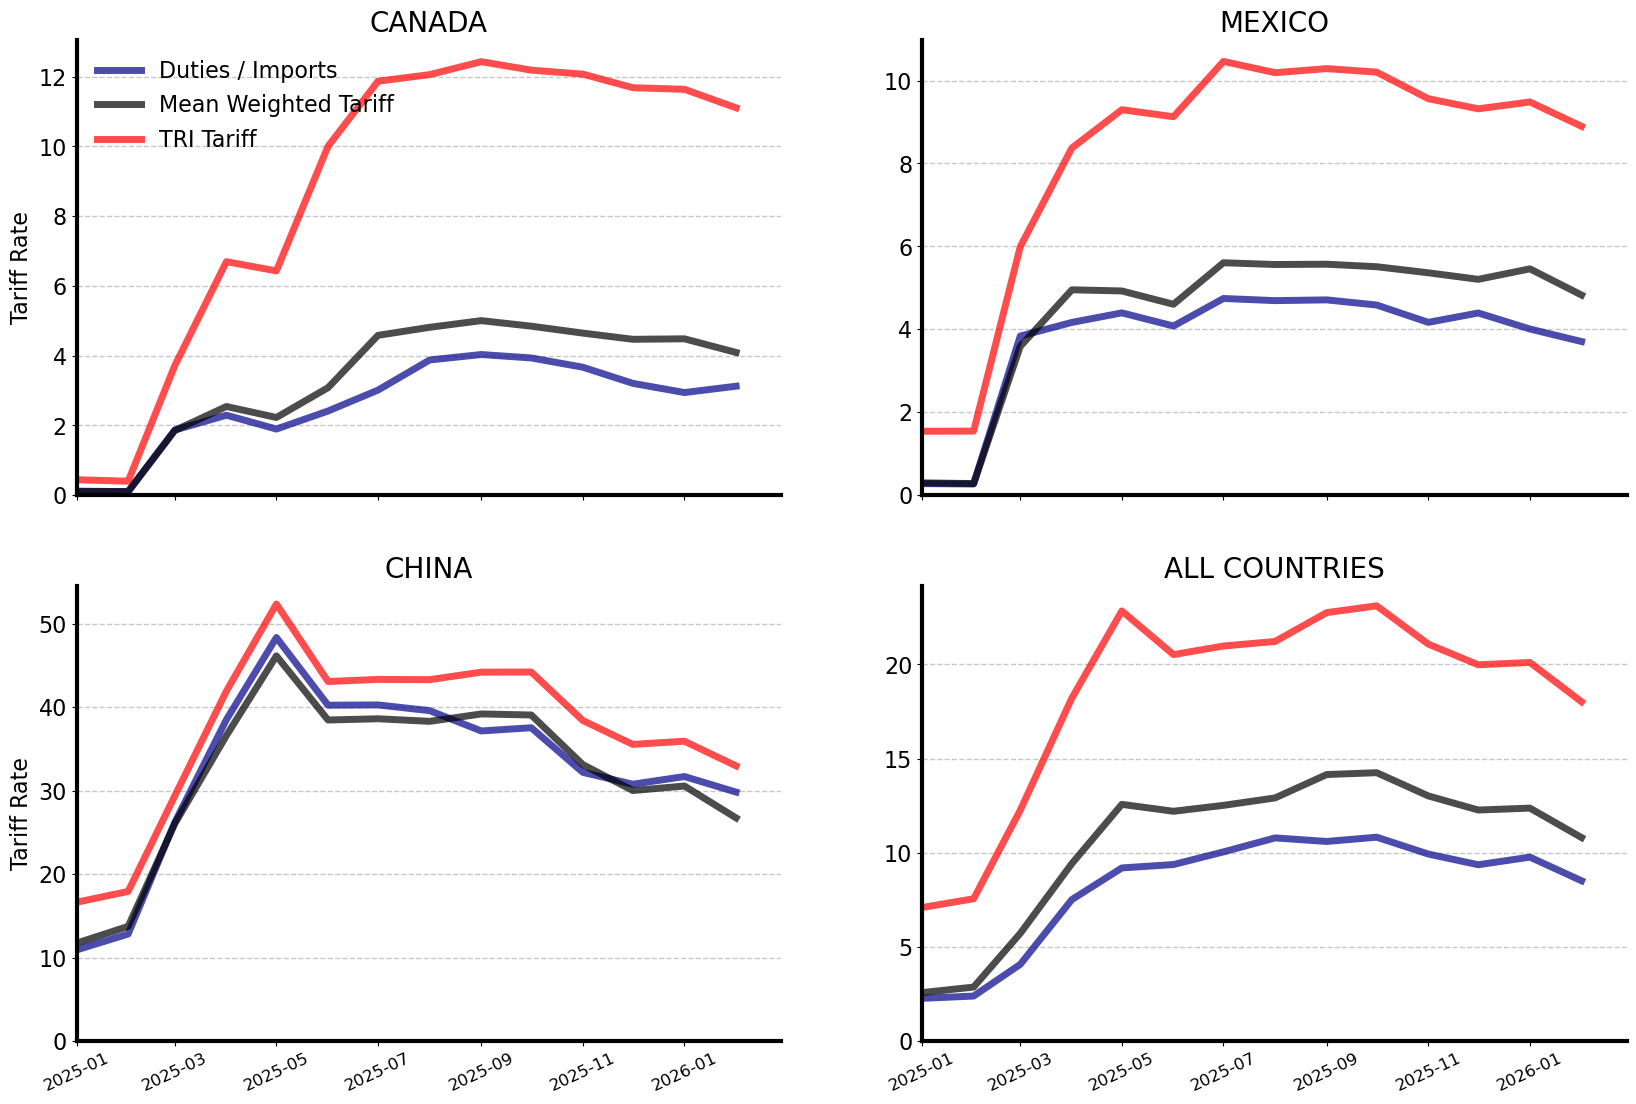

In [31]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, sharex = True, figsize = (20,13)) 

countries = ["CANADA", "MEXICO", "CHINA", "ALL COUNTRIES"]

ax = ax.ravel() # Here is the trick here, ax is a 2 by 2 array. We want to work through it in a loop...so
                # one way to do this is to flatten stuff out, make it a 4 by 1 array. The ravel command 
                # does this...
    
for i, (ax, country) in enumerate(zip(ax, countries)):

    foo = metrics_df[metrics_df["CTY_NAME"] == country].copy()

    ax.plot(foo.date, 100*foo["simplemean"], color = "darkblue", alpha = 0.7, linewidth = 5, label = "Duties / Imports")

    ax.plot(foo.date, 100*foo["meanweighted"], color = "black", alpha = 0.7, linewidth = 5, label = "Mean Weighted Tariff")

    ax.plot(foo.date, 100*foo["sqrtariff"], color = "red", alpha = 0.7, linewidth = 5, label = "TRI Tariff")

    ax.set_title( foo["CTY_NAME"].iloc[0], fontsize = 20)

    plot_end = pd.to_datetime(target_date, format="%Y-%m") + pd.offsets.MonthEnd(1)
    ax.set_xlim([dt.datetime(2025,1,1), plot_end])

    ax.set_ylim(bottom=0)

    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=16)  # Change font size of y-axis tick labels

    ax.spines["right"].set_visible(False)

    ax.spines["top"].set_visible(False)

    ax.spines["left"].set_linewidth(3)

    ax.spines["bottom"].set_linewidth(3)

    ax.grid(axis='y', linewidth=1, linestyle='--', alpha=0.7)

    if i == 0:  # Only show legend in first plot
        ax.legend(
            fontsize=16,           # Font size
            frameon=False,         # No box
            loc='upper left',     # Position
            ncol=1                 # Number of columns
        )

        ax.set_ylabel("Tariff Rate", fontsize=16)

    if i == 2:

        ax.set_ylabel("Tariff Rate", fontsize=16)


plt.savefig(figfile+"panel-tariffs.png", bbox_inches = "tight")

plt.savefig(figfile+"panel-tariffs.pdf", bbox_inches = "tight")

plt.show()

In [32]:
country_list20 = pd.read_csv("C:\\heroku\\how-restrictive-us-trade\\data\\country-list-20.csv", header=None, names=["CTY_CODE"])

metrics_df_2025 = create_tariff_metrics_by_date_country(country_list20, [target_date], weight_year="2024")


Processing date: 2026-02
Processed 5700: CHINA
Processed 2010: MEXICO
Processed 1220: CANADA
Processed 5880: JAPAN
Processed 4280: GERMANY
Processed 5800: KOREA, SOUTH
Processed 5520: VIETNAM
Processed 5830: TAIWAN
Processed 4190: IRELAND
Processed 5330: INDIA
Processed 4120: UNITED KINGDOM
Processed 4759: ITALY
Processed 4279: FRANCE
Processed 4419: SWITZERLAND
Processed 5570: MALAYSIA
Processed 5490: THAILAND
Processed 3510: BRAZIL
Processed 5590: SINGAPORE
Processed 4210: NETHERLANDS
Processed 5600: INDONESIA


In [33]:
metrics_df_2025[["CTY_NAME", "sqrtariff", "meanweighted", "simplemean"]]

,CTY_NAME,sqrtariff,meanweighted,simplemean
0,ALL COUNTRIES,0.183666,0.110993,0.086714
1,CHINA,0.329734,0.267374,0.298341
2,MEXICO,0.088955,0.048260,0.037050
3,CANADA,0.111052,0.040912,0.031236
4,JAPAN,0.147744,0.115724,0.113457
5,GERMANY,0.145434,0.105032,0.111516
6,"KOREA, SOUTH",0.151697,0.115633,0.089134
7,VIETNAM,0.211787,0.162994,0.117293
8,TAIWAN,0.157848,0.090905,0.033190
9,IRELAND,0.046189,0.017578,0.021989


In [34]:
foo = metrics_df_2025[["CTY_NAME", "sqrtariff", "meanweighted", "simplemean"]].iloc[0:21]

foo = foo.sort_values(by="sqrtariff", ascending=False).reset_index(drop=True)

foo[["sqrtariff", "meanweighted", "simplemean"]] = 100*foo[["sqrtariff", "meanweighted", "simplemean"]]

foo["CTY_NAME"] = foo["CTY_NAME"].str.title()

foo.rename(columns={
    "CTY_NAME": "Country",
    "sqrtariff": "TRI Tariff",
    "meanweighted": "Mean Weighted Tariff",
    "simplemean": "Duties / Imports"
}, inplace=True)

formatted_date = pd.to_datetime(target_date, format="%Y-%m").strftime("%B %Y")

foo.to_latex(tabletex,
            index=False,
            escape=False,
            float_format="%.1f",
            caption=f'Tariff Metrics by Sector: {formatted_date}',
            label='tab:tariff_metrics')

# Fix centering in the table
with open(tabletex, 'r') as f:
    content = f.read()

# Insert \centering after \begin{table}
content = content.replace(r'\begin{table}', r'\begin{table}' + '\n\\centering')

with open(tabletex, 'w') as f:
    f.write(content)

In [35]:
metrics_df_2025.sort_values(by="sqrtariff", ascending=False).iloc[0:21]

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total
1,2026-02,CHINA,0.329734,0.267374,0.298341,5.160176e+09
17,2026-02,BRAZIL,0.252904,0.146535,0.141791,2.968784e+08
10,2026-02,INDIA,0.228320,0.155905,0.154027,9.569161e+08
20,2026-02,INDONESIA,0.226478,0.188708,0.196490,4.403814e+08
7,2026-02,VIETNAM,0.211787,0.162994,0.117293,1.796294e+09
0,2026-02,ALL COUNTRIES,0.183666,0.110993,0.086714,1.705073e+10
16,2026-02,THAILAND,0.179488,0.136754,0.074687,6.338151e+08
8,2026-02,TAIWAN,0.157848,0.090905,0.033190,6.228807e+08
6,2026-02,"KOREA, SOUTH",0.151697,0.115633,0.089134,9.558092e+08
4,2026-02,JAPAN,0.147744,0.115724,0.113457,1.122312e+09


In [36]:
metrics_df.head()

,date,CTY_NAME,sqrtariff,meanweighted,simplemean,duty_total,flag,color
0,2024-01-01,ALL COUNTRIES,0.069033,0.025379,0.025379,5.842121e+09,https://em-content.zobj.net/thumbs/120/twitter...,#000000
1,2024-01-01,CHINA,0.160054,0.113511,0.113511,4.007985e+09,https://flagcdn.com/w40/cn.png,#DE2910
2,2024-01-01,MEXICO,0.015009,0.002634,0.002634,9.943317e+07,https://flagcdn.com/w40/mx.png,#006847
3,2024-01-01,CANADA,0.004157,0.001022,0.001022,3.424321e+07,https://flagcdn.com/w40/ca.png,#FF0000
4,2024-01-01,JAPAN,0.024215,0.015219,0.015219,1.985776e+08,https://flagcdn.com/w40/jp.png,#BC002D
